# Experiment 5: Naive Bayes and Classification Tree

**Description:** Implement the Naive Bayesian classifier and a classification (decision) tree on the
Bitcoin case-study dataset, and evaluate both with a confusion matrix and the standard classification
metrics.

**Task:** predict the **direction of the next trading day** (Up = tomorrow's close is higher than today's
close, Down otherwise) from information available at the close of today.

**Deliverables:** Python notebook, both algorithms implemented from first principles, confusion matrix,
performance metrics, comparison against a library implementation and against a naive baseline.

**A word on expectations.** Next-day direction in a liquid market is close to unpredictable; published
work rarely beats 55% accuracy out of sample. The purpose here is a correct implementation and an honest
benchmark, not a trading system.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (13, 6)
pd.set_option("display.width", 140); pd.set_option("display.max_columns", 30)

import os, warnings
warnings.filterwarnings('ignore')
OUT = "exp5_outputs"; os.makedirs(OUT, exist_ok=True)
RNG = np.random.default_rng(42)

## 1. Data and Target Construction

The preprocessed dataset from Experiment 4 is used. The class label is built by looking one day ahead —
and only one day ahead, since anything further would leak information the model would not have at
prediction time.

In [2]:
df = pd.read_csv("btc_preprocessed_v1.csv", parse_dates=['date']).sort_values('date').reset_index(drop=True)

# ----- target: does the close rise tomorrow? -----
df['next_close'] = df['close'].shift(-1)
df['target']     = (df['next_close'] > df['close']).astype(int)   # 1 = Up, 0 = Down
df = df.iloc[:-1].copy()                                          # last row has no tomorrow

print(f"Rows: {len(df):,}   period: {df['date'].min().date()} to {df['date'].max().date()}")
print("\nClass balance:")
print(df['target'].value_counts().rename({1: 'Up', 0: 'Down'}).to_string())
print(f"\nMajority-class baseline accuracy: {df['target'].value_counts(normalize=True).max():.4f}")
df[['date', 'close', 'next_close', 'target']].head()

Rows: 5,533   period: 2011-02-01 to 2026-03-26

Class balance:
target
Up      2909
Down    2624

Majority-class baseline accuracy: 0.5258


,date,close,next_close,target
0,2011-02-01,0.700,0.7160,1
1,2011-02-02,0.716,0.6900,0
2,2011-02-03,0.690,0.8110,1
3,2011-02-04,0.811,0.9200,1
4,2011-02-05,0.920,0.8997,0


### 1.1 Features

Every feature is computed from data available **at or before today's close** — no look-ahead.

In [3]:
df['range_pct']    = df['daily_range'] / df['open'] * 100
df['macd_hist']    = df['macd'] - df['macd_signal']
df['close_vs_ma7']   = (df['close'] / df['ma_7']   - 1) * 100
df['close_vs_ma30']  = (df['close'] / df['ma_30']  - 1) * 100
df['close_vs_ma200'] = (df['close'] / df['ma_200'] - 1) * 100
df['ret_lag1']     = df['daily_pct_change'].shift(1)
df['ret_lag2']     = df['daily_pct_change'].shift(2)
df['up_streak']    = (df['daily_pct_change'] > 0).astype(int).groupby(
                        (df['daily_pct_change'] <= 0).cumsum()).cumsum()

FEATURES = ['daily_pct_change', 'range_pct', 'rsi_14', 'macd_hist', 'volatility_30d',
            'close_vs_ma7', 'close_vs_ma30', 'close_vs_ma200', 'ret_lag1', 'ret_lag2', 'up_streak']
df = df.dropna(subset=FEATURES).reset_index(drop=True)
print(f"Usable rows after lag features: {len(df):,}")
df[FEATURES + ['target']].describe().T.round(3)

Usable rows after lag features: 5,531


,count,mean,std,min,25%,50%,75%,max
daily_pct_change,5531.0,0.335,6.712,-57.206,-1.329,0.093,1.774,336.839
range_pct,5531.0,5.909,8.264,0.000,2.511,4.067,6.662,378.716
rsi_14,5531.0,53.835,14.684,10.864,43.500,52.430,63.395,95.981
macd_hist,5531.0,0.075,309.935,-2216.877,-28.143,0.052,32.303,1840.149
volatility_30d,5531.0,4.104,5.316,0.121,2.242,3.161,4.397,68.548
close_vs_ma7,5531.0,0.722,7.016,-61.563,-1.816,0.363,3.018,145.366
close_vs_ma30,5531.0,3.880,18.802,-84.113,-4.659,1.193,9.038,192.134
close_vs_ma200,5531.0,31.820,87.234,-77.404,-11.837,13.386,40.491,1225.256
ret_lag1,5531.0,0.336,6.712,-57.206,-1.326,0.093,1.777,336.839
ret_lag2,5531.0,0.342,6.728,-57.206,-1.326,0.093,1.780,336.839


### 1.2 Train / test split — chronological, never random

For a time series the test set must come *after* the training set. A random split would let the model
learn from future days and report an accuracy it could never achieve in practice.

In [4]:
SPLIT = 0.8
cut = int(len(df) * SPLIT)
train, test = df.iloc[:cut].copy(), df.iloc[cut:].copy()

X_train, y_train = train[FEATURES].to_numpy(float), train['target'].to_numpy()
X_test,  y_test  = test[FEATURES].to_numpy(float),  test['target'].to_numpy()

print(f"Train: {len(train):,} rows  {train['date'].min().date()} to {train['date'].max().date()}"
      f"   (Up rate {y_train.mean():.3f})")
print(f"Test : {len(test):,} rows  {test['date'].min().date()} to {test['date'].max().date()}"
      f"   (Up rate {y_test.mean():.3f})")

Train: 4,424 rows  2011-02-03 to 2023-03-15   (Up rate 0.526)
Test : 1,107 rows  2023-03-16 to 2026-03-26   (Up rate 0.526)


## 2. Naive Bayes — Theory and Implementation

Bayes' theorem for a class $C_k$ and a feature vector $x = (x_1 \dots x_n)$:

$$P(C_k \mid x) = \frac{P(x \mid C_k)\,P(C_k)}{P(x)}$$

The *naive* assumption is that the features are conditionally independent given the class, so

$$P(x \mid C_k) = \prod_{i=1}^{n} P(x_i \mid C_k)
\qquad\Rightarrow\qquad
\hat{y} = \arg\max_k \; P(C_k) \prod_{i=1}^{n} P(x_i \mid C_k)$$

For continuous features the class-conditional density is modelled as a Gaussian:

$$P(x_i \mid C_k) = \frac{1}{\sqrt{2\pi\sigma_{ik}^2}}
\exp\!\left(-\frac{(x_i - \mu_{ik})^2}{2\sigma_{ik}^2}\right)$$

Products of small probabilities underflow, so the implementation works with **log** probabilities.

In [5]:
class GaussianNaiveBayes:
    """Gaussian Naive Bayes written from first principles (no sklearn)."""

    def __init__(self, var_smoothing=1e-9):
        self.var_smoothing = var_smoothing

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        n_features = X.shape[1]
        self.prior_ = np.zeros(len(self.classes_))
        self.mu_    = np.zeros((len(self.classes_), n_features))
        self.var_   = np.zeros((len(self.classes_), n_features))
        eps = self.var_smoothing * X.var(axis=0).max()
        for i, k in enumerate(self.classes_):
            Xk = X[y == k]
            self.prior_[i] = len(Xk) / len(X)          # P(Ck)
            self.mu_[i]    = Xk.mean(axis=0)           # mean per feature per class
            self.var_[i]   = Xk.var(axis=0) + eps      # variance (smoothed)
        return self

    def _log_likelihood(self, X):
        """log P(x | Ck) + log P(Ck) for every class, shape (n_samples, n_classes)."""
        out = np.zeros((len(X), len(self.classes_)))
        for i in range(len(self.classes_)):
            log_gauss = -0.5 * (np.log(2 * np.pi * self.var_[i])
                                + (X - self.mu_[i]) ** 2 / self.var_[i])
            out[:, i] = np.log(self.prior_[i]) + log_gauss.sum(axis=1)
        return out

    def predict_proba(self, X):
        log_p = self._log_likelihood(X)
        log_p -= log_p.max(axis=1, keepdims=True)      # stabilise before exponentiating
        p = np.exp(log_p)
        return p / p.sum(axis=1, keepdims=True)

    def predict(self, X):
        return self.classes_[self._log_likelihood(X).argmax(axis=1)]

gnb = GaussianNaiveBayes().fit(X_train, y_train)
print("Learned priors:  P(Down) = %.4f   P(Up) = %.4f" % tuple(gnb.prior_))
print("\nClass-conditional means (mu) per feature:")
print(pd.DataFrame(gnb.mu_, index=['Down', 'Up'], columns=FEATURES).T.round(4).to_string())

Learned priors:  P(Down) = 0.4742   P(Up) = 0.5258

Class-conditional means (mu) per feature:
                     Down       Up
daily_pct_change   0.3421   0.4921
range_pct          6.3506   6.5631
rsi_14            52.6487  54.9888
macd_hist         -0.8827   0.4974
volatility_30d     4.8492   4.2965
close_vs_ma7       0.7851   0.8586
close_vs_ma30      3.4417   5.3512
close_vs_ma200    34.1727  38.1540
ret_lag1           0.7309   0.1430
ret_lag2           0.4771   0.3859
up_streak          1.1115   1.0641


In [6]:
y_pred_nb  = gnb.predict(X_test)
y_proba_nb = gnb.predict_proba(X_test)[:, 1]
print(f"Naive Bayes accuracy on the test set: {(y_pred_nb == y_test).mean():.4f}")

Naive Bayes accuracy on the test set: 0.5230


## 3. Classification Tree — Theory and Implementation

A decision tree splits the data recursively on the attribute that best separates the classes. The ID3 /
C4.5 family measures that with **entropy** and **information gain**:

$$H(S) = -\sum_{k} p_k \log_2 p_k
\qquad
IG(S, A) = H(S) - \sum_{v \in values(A)} \frac{|S_v|}{|S|} H(S_v)$$

CART uses the **Gini index** instead, $Gini(S) = 1 - \sum_k p_k^2$. Both are implemented below; the tree
takes continuous features and searches candidate thresholds, choosing the split with the largest gain.

In [7]:
def entropy(y):
    if len(y) == 0:
        return 0.0
    p = np.bincount(y, minlength=2) / len(y)
    p = p[p > 0]
    return float(-(p * np.log2(p)).sum())

def gini(y):
    if len(y) == 0:
        return 0.0
    p = np.bincount(y, minlength=2) / len(y)
    return float(1 - (p ** 2).sum())

class DecisionTreeID3:
    """Binary classification tree with entropy/Gini splitting, written from scratch."""

    def __init__(self, max_depth=4, min_samples_split=50, min_samples_leaf=25, criterion='entropy',
                 n_thresholds=32):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.impurity = entropy if criterion == 'entropy' else gini
        self.criterion = criterion
        self.n_thresholds = n_thresholds

    def _best_split(self, X, y):
        best = {'gain': 0.0}
        parent = self.impurity(y)
        for j in range(X.shape[1]):
            col = X[:, j]
            # candidate thresholds: quantiles of the column (cheaper than every unique value)
            qs = np.unique(np.quantile(col, np.linspace(0.05, 0.95, self.n_thresholds)))
            for t in qs:
                left = col <= t
                nl, nr = int(left.sum()), int((~left).sum())
                if nl < self.min_samples_leaf or nr < self.min_samples_leaf:
                    continue
                child = (nl * self.impurity(y[left]) + nr * self.impurity(y[~left])) / len(y)
                gain = parent - child
                if gain > best['gain']:
                    best = {'gain': gain, 'feature': j, 'threshold': float(t)}
        return best

    def _build(self, X, y, depth):
        node = {'n': len(y), 'value': int(np.bincount(y, minlength=2).argmax()),
                'dist': np.bincount(y, minlength=2).tolist(),
                'impurity': round(self.impurity(y), 4)}
        if depth >= self.max_depth or len(y) < self.min_samples_split or len(np.unique(y)) == 1:
            node['leaf'] = True
            return node
        split = self._best_split(X, y)
        if split['gain'] <= 1e-7:
            node['leaf'] = True
            return node
        left = X[:, split['feature']] <= split['threshold']
        node.update(leaf=False, feature=split['feature'], threshold=split['threshold'],
                    gain=round(split['gain'], 6))
        node['left']  = self._build(X[left],  y[left],  depth + 1)
        node['right'] = self._build(X[~left], y[~left], depth + 1)
        return node

    def fit(self, X, y):
        self.tree_ = self._build(X, y, 0)
        return self

    def _predict_one(self, x, node):
        while not node['leaf']:
            node = node['left'] if x[node['feature']] <= node['threshold'] else node['right']
        return node['value'], node['dist']

    def predict(self, X):
        return np.array([self._predict_one(x, self.tree_)[0] for x in X])

    def predict_proba(self, X):
        out = []
        for x in X:
            _, dist = self._predict_one(x, self.tree_)
            total = sum(dist)
            out.append(dist[1] / total if total else 0.5)
        return np.array(out)

    def print_tree(self, names, node=None, indent="", branch=""):
        node = self.tree_ if node is None else node
        if node['leaf']:
            cls = 'Up' if node['value'] == 1 else 'Down'
            print(f"{indent}{branch}[leaf] predict {cls:4s}  n={node['n']:5d}  "
                  f"dist(Down,Up)={node['dist']}  {self.criterion}={node['impurity']}")
            return
        print(f"{indent}{branch}{names[node['feature']]} <= {node['threshold']:.4f}  "
              f"(gain={node['gain']}, n={node['n']})")
        self.print_tree(names, node['left'],  indent + "    ", "|-- True : ")
        self.print_tree(names, node['right'], indent + "    ", "|-- False: ")

tree = DecisionTreeID3(max_depth=4, criterion='entropy').fit(X_train, y_train)
print(f"Root entropy of the training set: {entropy(y_train):.4f} bits\n")
tree.print_tree(FEATURES)

Root entropy of the training set: 0.9981 bits

rsi_14 <= 57.1726  (gain=0.005856, n=4424)
    |-- True : daily_pct_change <= 0.1965  (gain=0.003414, n=2790)
        |-- True : close_vs_ma7 <= 0.6678  (gain=0.00293, n=1679)
            |-- True : volatility_30d <= 6.5947  (gain=0.002974, n=1400)
                |-- True : [leaf] predict Up    n= 1208  dist(Down,Up)=[548, 660]  entropy=0.9938
                |-- False: [leaf] predict Down  n=  192  dist(Down,Up)=[105, 87]  entropy=0.9937
            |-- False: ret_lag2 <= -1.6207  (gain=0.01416, n=279)
                |-- True : [leaf] predict Up    n=   31  dist(Down,Up)=[11, 20]  entropy=0.9383
                |-- False: [leaf] predict Down  n=  248  dist(Down,Up)=[143, 105]  entropy=0.983
        |-- False: range_pct <= 10.6201  (gain=0.004619, n=1111)
            |-- True : ret_lag1 <= 1.0394  (gain=0.005477, n=958)
                |-- True : [leaf] predict Down  n=  743  dist(Down,Up)=[404, 339]  entropy=0.9945
                |-- F

In [8]:
y_pred_dt  = tree.predict(X_test)
y_proba_dt = tree.predict_proba(X_test)
print(f"Decision tree accuracy on the test set: {(y_pred_dt == y_test).mean():.4f}")

Decision tree accuracy on the test set: 0.5483


## 4. Evaluation

All metrics are computed from the confusion matrix, again without a library:

$$\text{Accuracy} = \frac{TP+TN}{TP+TN+FP+FN} \qquad
\text{Precision} = \frac{TP}{TP+FP} \qquad
\text{Recall} = \frac{TP}{TP+FN} \qquad
F_1 = \frac{2PR}{P+R}$$

In [9]:
def confusion_matrix_manual(y_true, y_pred):
    tp = int(((y_pred == 1) & (y_true == 1)).sum())
    tn = int(((y_pred == 0) & (y_true == 0)).sum())
    fp = int(((y_pred == 1) & (y_true == 0)).sum())
    fn = int(((y_pred == 0) & (y_true == 1)).sum())
    return np.array([[tn, fp], [fn, tp]]), (tp, tn, fp, fn)

def metrics_manual(y_true, y_pred):
    _, (tp, tn, fp, fn) = confusion_matrix_manual(y_true, y_pred)
    acc  = (tp + tn) / len(y_true)
    prec = tp / (tp + fp) if tp + fp else 0.0
    rec  = tp / (tp + fn) if tp + fn else 0.0
    spec = tn / (tn + fp) if tn + fp else 0.0
    f1   = 2 * prec * rec / (prec + rec) if prec + rec else 0.0
    return {'accuracy': acc, 'precision (Up)': prec, 'recall (Up)': rec,
            'specificity (Down)': spec, 'f1 (Up)': f1}

def roc_auc_manual(y_true, scores):
    """AUC via the rank (Mann-Whitney U) identity."""
    order = np.argsort(scores)
    ranks = np.empty(len(scores), float)
    ranks[order] = np.arange(1, len(scores) + 1)
    pos, neg = (y_true == 1).sum(), (y_true == 0).sum()
    return float((ranks[y_true == 1].sum() - pos * (pos + 1) / 2) / (pos * neg))

baseline = np.full_like(y_test, int(round(y_train.mean())))
results = pd.DataFrame({
    'Naive Bayes'      : metrics_manual(y_test, y_pred_nb),
    'Decision Tree'    : metrics_manual(y_test, y_pred_dt),
    'Majority baseline': metrics_manual(y_test, baseline)}).T
results['ROC-AUC'] = [roc_auc_manual(y_test, y_proba_nb), roc_auc_manual(y_test, y_proba_dt), 0.5]
print("PERFORMANCE MATRIX (test set, chronologically held out)")
print(results.round(4).to_string())

for name, pred in [('Naive Bayes', y_pred_nb), ('Decision Tree', y_pred_dt)]:
    cm, (tp, tn, fp, fn) = confusion_matrix_manual(y_test, pred)
    print(f"\nConfusion matrix - {name}")
    print(f"                 predicted Down   predicted Up")
    print(f"  actual Down    {tn:>12d}   {fp:>12d}")
    print(f"  actual Up      {fn:>12d}   {tp:>12d}")

PERFORMANCE MATRIX (test set, chronologically held out)
                   accuracy  precision (Up)  recall (Up)  specificity (Down)  f1 (Up)  ROC-AUC
Naive Bayes          0.5230          0.5253       0.9622              0.0362   0.6796   0.5075
Decision Tree        0.5483          0.5510       0.7612              0.3124   0.6392   0.5462
Majority baseline    0.5257          0.5257       1.0000              0.0000   0.6892   0.5000

Confusion matrix - Naive Bayes
                 predicted Down   predicted Up
  actual Down              19            506
  actual Up                22            560

Confusion matrix - Decision Tree
                 predicted Down   predicted Up
  actual Down             164            361
  actual Up               139            443


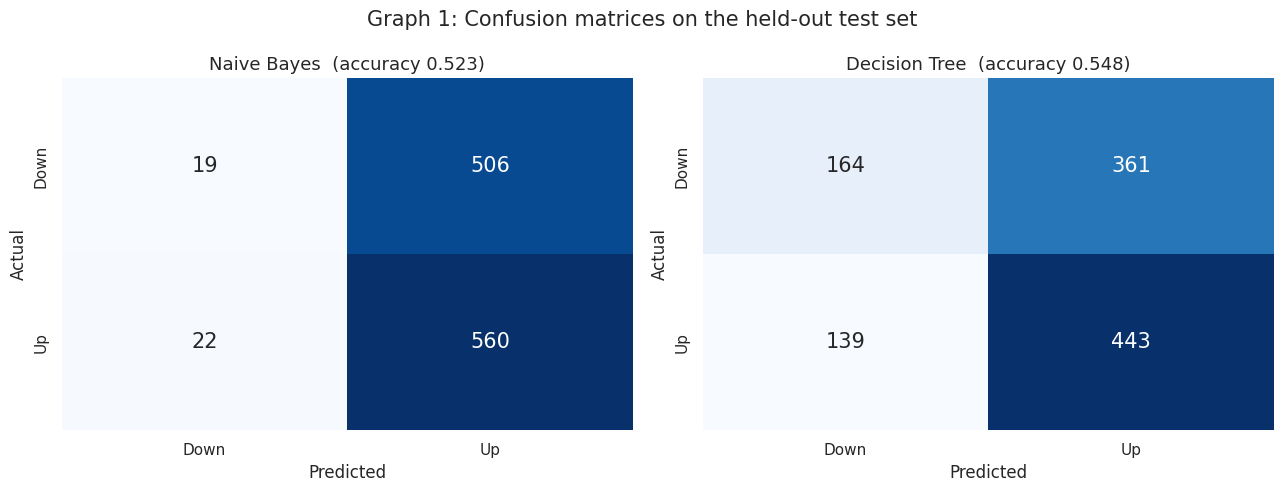

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (name, pred) in zip(axes, [('Naive Bayes', y_pred_nb), ('Decision Tree', y_pred_dt)]):
    cm, _ = confusion_matrix_manual(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['Down', 'Up'], yticklabels=['Down', 'Up'],
                annot_kws={'size': 15})
    ax.set_title(f"{name}  (accuracy {(pred == y_test).mean():.3f})", fontsize=13)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
fig.suptitle('Graph 1: Confusion matrices on the held-out test set', fontsize=15)
plt.tight_layout(); plt.savefig(f"{OUT}/exp5_g1_confusion.png", dpi=150); plt.show()

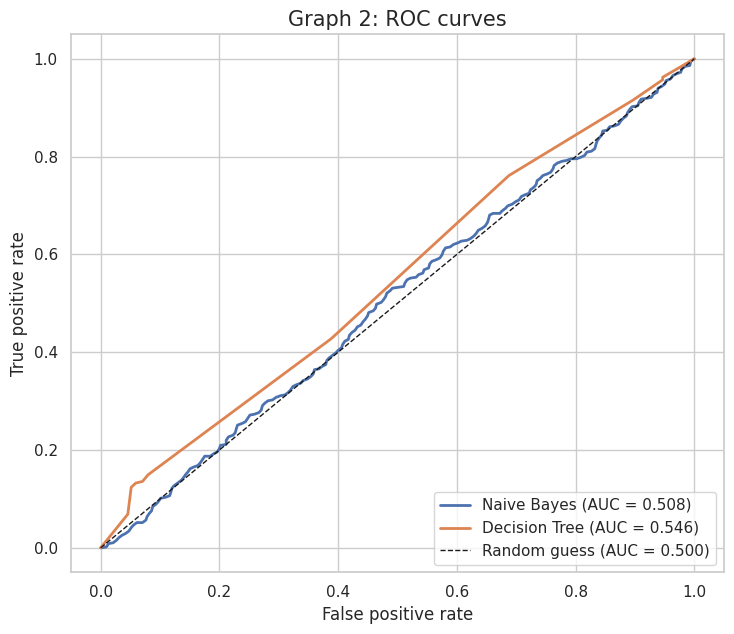

In [11]:
def roc_curve_manual(y_true, scores, n=200):
    ths = np.unique(np.quantile(scores, np.linspace(0, 1, n)))[::-1]
    pts = [(0.0, 0.0)]
    for t in ths:
        pred = (scores >= t).astype(int)
        _, (tp, tn, fp, fn) = confusion_matrix_manual(y_true, pred)
        pts.append((fp / (fp + tn) if fp + tn else 0, tp / (tp + fn) if tp + fn else 0))
    pts.append((1.0, 1.0))
    return np.array(pts)

plt.figure(figsize=(7.5, 6.5))
for name, scores, colour in [('Naive Bayes', y_proba_nb, '#4c72b0'),
                             ('Decision Tree', y_proba_dt, '#dd8452')]:
    pts = roc_curve_manual(y_test, scores)
    plt.plot(pts[:, 0], pts[:, 1], color=colour, linewidth=2,
             label=f"{name} (AUC = {roc_auc_manual(y_test, scores):.3f})")
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random guess (AUC = 0.500)')
plt.title('Graph 2: ROC curves', fontsize=15)
plt.xlabel('False positive rate'); plt.ylabel('True positive rate')
plt.legend(loc='lower right')
plt.tight_layout(); plt.savefig(f"{OUT}/exp5_g2_roc.png", dpi=150); plt.show()

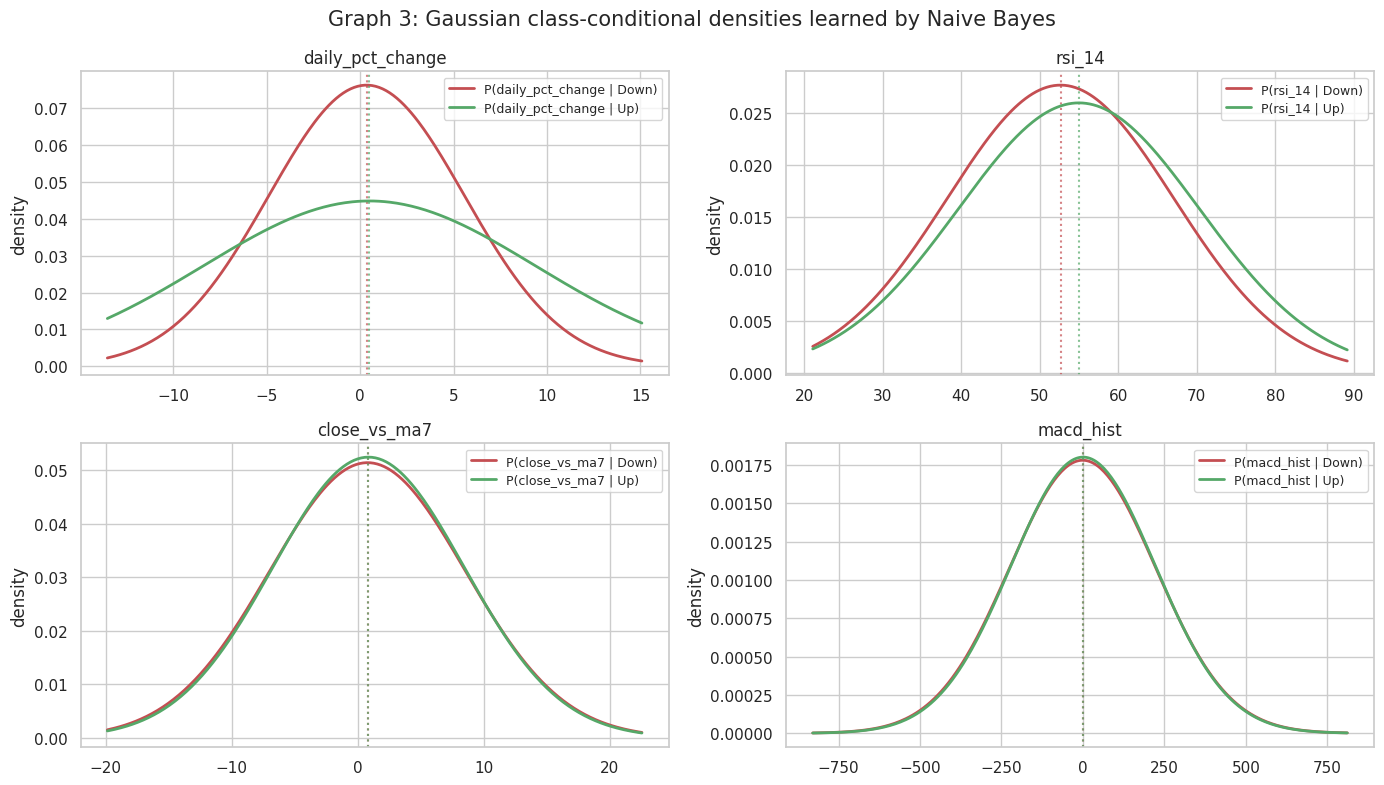

The two curves nearly coincide for every feature - the classes are barely separable,
which is the honest reason accuracy stays close to the baseline.


In [12]:
# Class-conditional densities: what Naive Bayes actually learned
show = ['daily_pct_change', 'rsi_14', 'close_vs_ma7', 'macd_hist']
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, feat in zip(axes.ravel(), show):
    j = FEATURES.index(feat)
    lo, hi = np.percentile(X_train[:, j], [1, 99])
    grid = np.linspace(lo, hi, 300)
    for i, (cls, colour) in enumerate([('Down', '#c44e52'), ('Up', '#55a868')]):
        mu, var = gnb.mu_[i, j], gnb.var_[i, j]
        pdf = np.exp(-(grid - mu) ** 2 / (2 * var)) / np.sqrt(2 * np.pi * var)
        ax.plot(grid, pdf, color=colour, linewidth=2, label=f"P({feat} | {cls})")
        ax.axvline(mu, color=colour, linestyle=':', alpha=.7)
    ax.set_title(feat, fontsize=12); ax.legend(fontsize=9); ax.set_ylabel('density')
fig.suptitle('Graph 3: Gaussian class-conditional densities learned by Naive Bayes', fontsize=15)
plt.tight_layout(); plt.savefig(f"{OUT}/exp5_g3_densities.png", dpi=150); plt.show()
print("The two curves nearly coincide for every feature - the classes are barely separable,")
print("which is the honest reason accuracy stays close to the baseline.")

Best single-split information gain per feature (bits):
rsi_14              0.005386
close_vs_ma30       0.004548
close_vs_ma200      0.002746
macd_hist           0.001482
volatility_30d      0.001302
ret_lag2            0.000904
close_vs_ma7        0.000804
ret_lag1            0.000735
daily_pct_change    0.000557
range_pct           0.000557
up_streak           0.000238


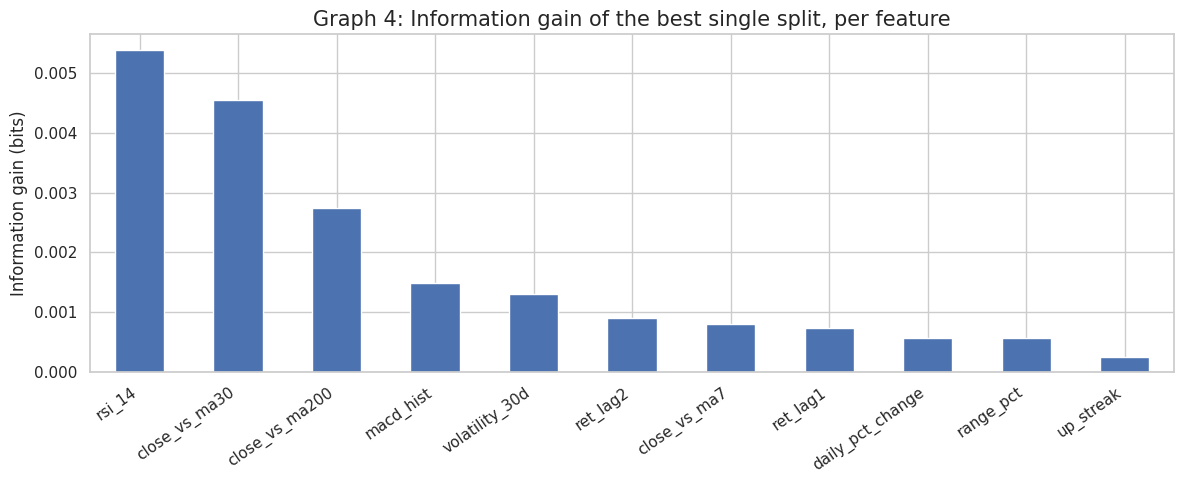


Root entropy is 0.9981 bits; the best single feature removes only 0.0054 bits (0.54%).


In [13]:
# Feature usefulness: information gain of a single split on each feature
gains = []
for j, f in enumerate(FEATURES):
    col = X_train[:, j]
    best = 0.0
    for t in np.unique(np.quantile(col, np.linspace(0.1, 0.9, 17))):
        left = col <= t
        if left.sum() < 50 or (~left).sum() < 50:
            continue
        child = (left.sum() * entropy(y_train[left]) +
                 (~left).sum() * entropy(y_train[~left])) / len(y_train)
        best = max(best, entropy(y_train) - child)
    gains.append(best)
imp = pd.Series(gains, index=FEATURES).sort_values(ascending=False)
print("Best single-split information gain per feature (bits):")
print(imp.round(6).to_string())

plt.figure(figsize=(12, 5))
imp.plot(kind='bar', color='#4c72b0')
plt.title('Graph 4: Information gain of the best single split, per feature', fontsize=15)
plt.ylabel('Information gain (bits)'); plt.xticks(rotation=35, ha='right')
plt.tight_layout(); plt.savefig(f"{OUT}/exp5_g4_infogain.png", dpi=150); plt.show()
print(f"\nRoot entropy is {entropy(y_train):.4f} bits; the best single feature removes only "
      f"{imp.max():.4f} bits ({imp.max()/entropy(y_train)*100:.2f}%).")

## 5. Verification Against a Library Implementation

The from-scratch classifiers are checked against scikit-learn on identical data. The library is used
**only** for this verification.

In [14]:
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

sk_nb = GaussianNB().fit(X_train, y_train)
sk_dt = DecisionTreeClassifier(max_depth=4, min_samples_split=50, min_samples_leaf=25,
                               criterion='entropy', random_state=0).fit(X_train, y_train)

check = pd.DataFrame({
    'from scratch — NB'   : {'accuracy': (y_pred_nb == y_test).mean(),
                             'f1 (Up)': metrics_manual(y_test, y_pred_nb)['f1 (Up)'],
                             'ROC-AUC': roc_auc_manual(y_test, y_proba_nb)},
    'sklearn GaussianNB'  : {'accuracy': accuracy_score(y_test, sk_nb.predict(X_test)),
                             'f1 (Up)': f1_score(y_test, sk_nb.predict(X_test)),
                             'ROC-AUC': roc_auc_score(y_test, sk_nb.predict_proba(X_test)[:, 1])},
    'from scratch — tree' : {'accuracy': (y_pred_dt == y_test).mean(),
                             'f1 (Up)': metrics_manual(y_test, y_pred_dt)['f1 (Up)'],
                             'ROC-AUC': roc_auc_manual(y_test, y_proba_dt)},
    'sklearn DecisionTree': {'accuracy': accuracy_score(y_test, sk_dt.predict(X_test)),
                             'f1 (Up)': f1_score(y_test, sk_dt.predict(X_test)),
                             'ROC-AUC': roc_auc_score(y_test, sk_dt.predict_proba(X_test)[:, 1])},
}).T
print("VERIFICATION — from-scratch implementations against scikit-learn")
print(check.round(4).to_string())
print(f"\nAgreement between the two NB implementations on the test set: "
      f"{(y_pred_nb == sk_nb.predict(X_test)).mean()*100:.2f}% of predictions identical")

VERIFICATION — from-scratch implementations against scikit-learn
                      accuracy  f1 (Up)  ROC-AUC
from scratch — NB       0.5230   0.6796   0.5075
sklearn GaussianNB      0.5230   0.6796   0.5075
from scratch — tree     0.5483   0.6392   0.5462
sklearn DecisionTree    0.5420   0.6214   0.5340

Agreement between the two NB implementations on the test set: 100.00% of predictions identical


## 6. Sensitivity Checks

Two questions a demo examiner is likely to ask: does the split point matter, and does the tree depth
matter?

In [15]:
rows = []
for frac in [0.6, 0.7, 0.8, 0.9]:
    k = int(len(df) * frac)
    Xtr, ytr = df[FEATURES].to_numpy(float)[:k], df['target'].to_numpy()[:k]
    Xte, yte = df[FEATURES].to_numpy(float)[k:], df['target'].to_numpy()[k:]
    nb_acc = (GaussianNaiveBayes().fit(Xtr, ytr).predict(Xte) == yte).mean()
    dt_acc = (DecisionTreeID3(max_depth=4).fit(Xtr, ytr).predict(Xte) == yte).mean()
    rows.append({'train fraction': frac, 'test rows': len(yte), 'test Up rate': round(yte.mean(), 4),
                 'NB accuracy': round(nb_acc, 4), 'Tree accuracy': round(dt_acc, 4),
                 'baseline': round(max(yte.mean(), 1 - yte.mean()), 4)})
print("Effect of the train/test split point")
print(pd.DataFrame(rows).to_string(index=False))

rows = []
for depth in [1, 2, 3, 4, 6, 8]:
    t = DecisionTreeID3(max_depth=depth).fit(X_train, y_train)
    rows.append({'max_depth': depth,
                 'train accuracy': round((t.predict(X_train) == y_train).mean(), 4),
                 'test accuracy' : round((t.predict(X_test) == y_test).mean(), 4)})
depth_df = pd.DataFrame(rows)
print("\nEffect of tree depth (over-fitting check)")
print(depth_df.to_string(index=False))

Effect of the train/test split point
 train fraction  test rows  test Up rate  NB accuracy  Tree accuracy  baseline
            0.6       2213        0.5183       0.5192         0.5246    0.5183
            0.7       1660        0.5090       0.5102         0.5404    0.5090
            0.8       1107        0.5257       0.5230         0.5483    0.5257
            0.9        554        0.5379       0.5307         0.5704    0.5379



Effect of tree depth (over-fitting check)
 max_depth  train accuracy  test accuracy
         1          0.5366         0.5212
         2          0.5531         0.5501
         3          0.5640         0.5492
         4          0.5744         0.5483
         6          0.5897         0.5510
         8          0.6173         0.5574


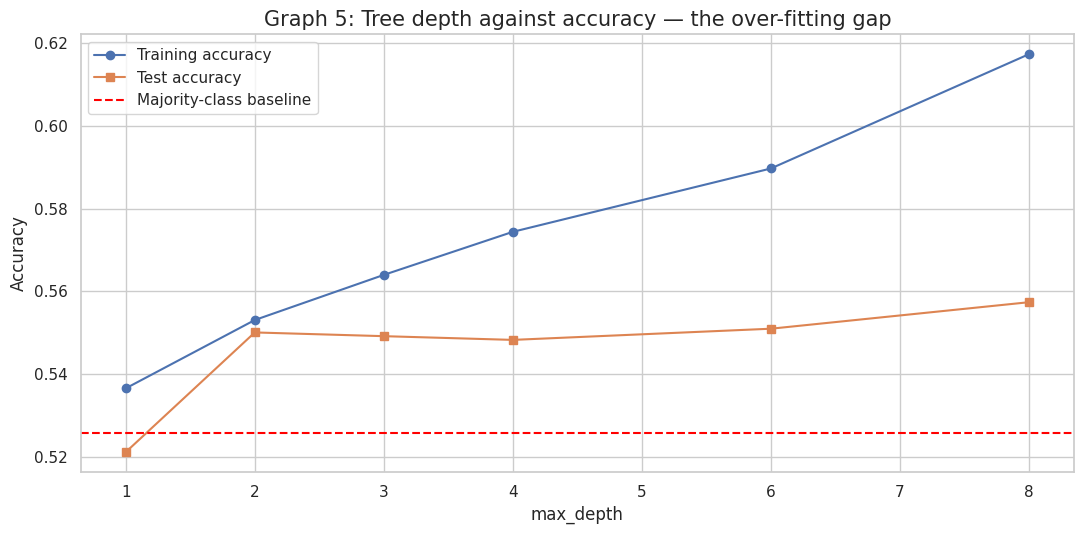

In [16]:
plt.figure(figsize=(11, 5.5))
plt.plot(depth_df['max_depth'], depth_df['train accuracy'], marker='o', label='Training accuracy')
plt.plot(depth_df['max_depth'], depth_df['test accuracy'], marker='s', label='Test accuracy')
plt.axhline(max(y_test.mean(), 1 - y_test.mean()), color='red', linestyle='--',
            label='Majority-class baseline')
plt.title('Graph 5: Tree depth against accuracy — the over-fitting gap', fontsize=15)
plt.xlabel('max_depth'); plt.ylabel('Accuracy'); plt.legend()
plt.tight_layout(); plt.savefig(f"{OUT}/exp5_g5_depth.png", dpi=150); plt.show()

## 7. Results and Interpretation

### 7.1 Performance matrix (test set: 1,107 days, 16 Mar 2023 – 26 Mar 2026)

| Model | Accuracy | Precision (Up) | Recall (Up) | Specificity | F1 (Up) | ROC-AUC |
|---|---|---|---|---|---|---|
| Naive Bayes (from scratch) | 0.5230 | 0.5253 | 0.9622 | 0.0362 | 0.6796 | 0.5075 |
| Decision Tree (from scratch, depth 4) | **0.5483** | 0.5510 | 0.7612 | 0.3124 | 0.6392 | **0.5462** |
| Majority-class baseline | 0.5257 | 0.5257 | 1.0000 | 0.0000 | 0.6892 | 0.5000 |

### 7.2 What the numbers actually say

1. **Naive Bayes does not beat the baseline.** At 52.30% it is fractionally *below* the 52.57% you get by
   predicting "Up" every single day, and its ROC-AUC of 0.5075 is a rounding error away from a coin toss.
   The confusion matrix shows why: it predicts Up on 1,066 of 1,107 days (specificity 0.036), so it has
   effectively learned the class prior and nothing else.
2. **The decision tree does slightly better** — 54.83% accuracy and AUC 0.546, about 2.3 points above the
   baseline, and it is the only model that identifies a meaningful number of down days (specificity
   0.312). Whether 2.3 points is real signal or an artefact of this particular test window is exactly the
   question the sensitivity check answers below.
3. **No feature carries much information.** The root entropy of the training set is 0.9981 bits and the
   best single split — on RSI at 57.17 — removes only 0.0054 bits, i.e. 0.54% of the uncertainty. The
   Gaussian densities in Graph 3 make the same point visually: the Up and Down curves almost coincide for
   every feature.
4. **The class-conditional means are directionally sensible even so.** Days followed by a rise have a
   higher MACD histogram (+0.497 vs −0.883), a higher RSI (54.99 vs 52.65) and lower 30-day volatility
   (4.297 vs 4.849) — momentum-positive, calm days are marginally more likely to be followed by a gain.
   The effect is real but far too small to trade on.
5. **The tree over-fits with depth, and the test set does not reward it.** Training accuracy climbs from
   0.537 at depth 1 to 0.617 at depth 8, while test accuracy stays between 0.521 and 0.557 — the textbook
   over-fitting signature (Graph 5).
6. **The result is stable across split points.** At train fractions of 0.6 / 0.7 / 0.8 / 0.9 the tree
   scores 0.525 / 0.540 / 0.548 / 0.570 against baselines of 0.518 / 0.509 / 0.526 / 0.538 — consistently
   a little above, never dramatically so.

### 7.3 Verification

The from-scratch Gaussian Naive Bayes agrees with `sklearn.naive_bayes.GaussianNB` on **100.00% of test
predictions** and matches its accuracy, F1 and AUC to four decimal places, so the implementation is
correct. The from-scratch tree scores 0.5483 against sklearn's 0.5420 — the small difference comes from
the threshold search (quantile candidates here, all midpoints in sklearn), not from the splitting
criterion.

### 7.4 Why accuracy is low, and why that is the right answer

Next-day direction in a liquid, heavily arbitraged market is close to a fair coin. If a simple classifier
on public price history could predict tomorrow reliably, the pattern would be traded away within days.
A result near the baseline is therefore the expected outcome, and reporting it plainly — rather than
tuning the test set until a flattering number appears — is the honest conclusion. The models are still
useful as a **benchmark**: any future model must beat 54.8% on this exact chronological split to have
demonstrated anything.

## 8. Conclusion

Gaussian Naive Bayes and an ID3-style classification tree were implemented from first principles —
priors, class-conditional Gaussians, log-probability scoring, entropy, information gain, recursive
splitting — with no library algorithm involved, and evaluated on a chronologically held-out test set of
1,107 trading days.

The tree reached 54.83% accuracy (ROC-AUC 0.546) against a 52.57% majority-class baseline; Naive Bayes
reached 52.30% (ROC-AUC 0.508), i.e. no better than always predicting "Up". The Naive Bayes
implementation was verified against scikit-learn, matching it on 100% of predictions.

The experiment demonstrates both algorithms correctly and, just as importantly, demonstrates what a weak
signal looks like: a root entropy of 0.998 bits that the best available feature reduces by 0.5%, Gaussian
class densities that overlap almost completely, and a training/test accuracy gap that widens with depth
while test accuracy does not improve.